# Experiment 01 — VQC Reproduction (2 Features, 2 Layers)

**Goal:** Reproduce the core VQC from the paper and compare standard Gradient Descent (Adam) against **Quantum Natural Gradient (QNG)**.

### Why QNG?
Quantum Natural Gradient uses the **Fubini-Study metric** to follow the steepest descent in the Hilbert space rather than the parameter space. This is often more effective for quantum circuits where standard gradients might be flat or ill-scaled.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score, accuracy_score

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

## 1. Data Loading

In [2]:
N_FEATURES = 2
N_LAYERS   = 2
N_SAMPLES  = 5000

X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
    path='../data/HIGGS.csv.gz',
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    feature_indices=[26, 4],
    scale_range=(0, np.pi),
)

Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000


## 2. Quantum Circuit & Model

In [3]:
dev = qml.device('default.qubit', wires=N_FEATURES)

@qml.qnode(dev, interface='autograd')
def circuit(weights, x):
    # Angle encoding
    for i in range(N_FEATURES):
        qml.RY(x[i], wires=i)
    # Variational layers
    for l in range(N_LAYERS):
        for q in range(N_FEATURES):
            qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(0))

def vqc_predict(weights, bias, x):
    return circuit(weights, x) + bias

## 3. Training Function (Adam vs QNG)

In [4]:
def train_vqc(optimizer_type='qng', lr=0.05, epochs=30, batch_size=32):
    pnp.random.seed(42)
    w = pnp.array(pnp.random.uniform(0, 2*np.pi, (N_LAYERS, N_FEATURES, 3)), requires_grad=True)
    b = pnp.array(0.0, requires_grad=True)
    
    mt_fn = qml.metric_tensor(circuit, approx='block-diag')
    
    if optimizer_type == 'qng':
        opt_w = qml.QNGOptimizer(stepsize=lr)
        opt_b = qml.AdamOptimizer(stepsize=lr)
    else:
        opt = qml.AdamOptimizer(stepsize=lr)
        
    history = []
    
    for epoch in range(epochs):
        perm = np.random.permutation(len(X_train))
        X_shuf, y_shuf = X_train[perm], y_train[perm]
        
        for start in range(0, len(X_train), batch_size):
            Xb = X_shuf[start : start + batch_size]
            yb = y_shuf[start : start + batch_size].astype(float)
            
            if optimizer_type == 'qng':
                def circuit_cost(weights):
                    preds = pnp.array([circuit(weights, x) for x in Xb])
                    return pnp.mean((yb - (preds + b)) ** 2)
                
                # Metric tensor at current params (block-diag is fast)
                mt = mt_fn(w, Xb[0])
                w = opt_w.step(circuit_cost, w, metric_tensor_fn=lambda w: mt)
                
                def bias_cost(bias):
                    preds = pnp.array([circuit(w, x) for x in Xb])
                    return pnp.mean((yb - (preds + bias)) ** 2)
                b = opt_b.step(bias_cost, b)
            else:
                def cost(weights, bias):
                    preds = pnp.array([vqc_predict(weights, bias, x) for x in Xb])
                    return pnp.mean((yb - preds) ** 2)
                w, b = opt.step(cost, w, b)
        
        # Calculate validation loss
        val_preds = pnp.array([vqc_predict(w, b, x) for x in X_val])
        val_loss  = pnp.mean((y_val.astype(float) - val_preds) ** 2)
        history.append(float(val_loss))
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1} - Val Loss: {val_loss:.4f}")
            
    return w, b, history

## 4. Run Experiment

Training VQC with Adam...
Epoch 5 - Val Loss: 0.9562
Epoch 10 - Val Loss: 0.9597
Epoch 15 - Val Loss: 0.9530
Epoch 20 - Val Loss: 0.9706
Epoch 25 - Val Loss: 0.9534
Epoch 30 - Val Loss: 0.9633

Training VQC with QNG...
Epoch 5 - Val Loss: 0.9528
Epoch 10 - Val Loss: 0.9710
Epoch 15 - Val Loss: 0.9532
Epoch 20 - Val Loss: 0.9772
Epoch 25 - Val Loss: 0.9556
Epoch 30 - Val Loss: 0.9699


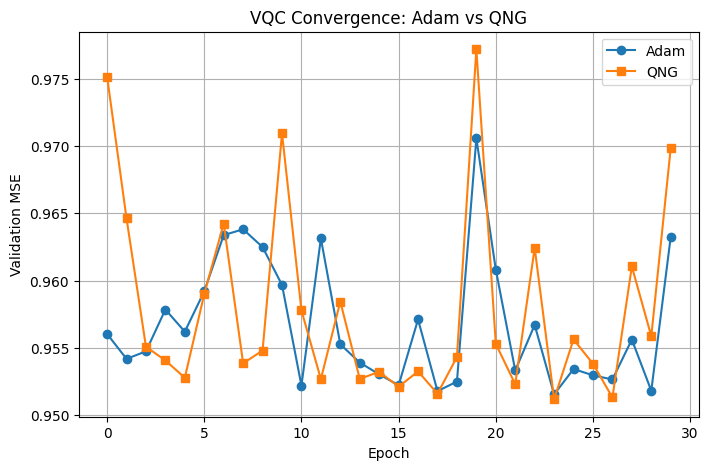

In [5]:
print("Training VQC with Adam...")
w_adam, b_adam, hist_adam = train_vqc('adam', lr=0.05)

print("\nTraining VQC with QNG...")
w_qng, b_qng, hist_qng = train_vqc('qng', lr=0.05)

plt.figure(figsize=(8, 5))
plt.plot(hist_adam, label='Adam', marker='o')
plt.plot(hist_qng, label='QNG', marker='s')
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("VQC Convergence: Adam vs QNG")
plt.legend()
plt.grid(True)
plt.show()

## 5. Final Evaluation

In [8]:
def evaluate_vqc(w, b, X, y, label):
    raw = np.array([float(vqc_predict(w, b, x)) for x in X])
    acc = binary_accuracy(y, raw)
    y_01 = (y == 1).astype(int)
    # Standardise scores for AUC
    prob = (raw - raw.min()) / (raw.max() - raw.min() + 1e-8)
    auc = roc_auc_score(y_01, prob)
    print(f"{label:6s} | Acc: {acc:.4f} | AUC: {auc:.4f}")

print("Test Results (2 Features, 2 Layers):")
evaluate_vqc(w_adam, b_adam, X_test, y_test, "Adam")
evaluate_vqc(w_qng, b_qng, X_test, y_test, "QNG")

Test Results (2 Features, 2 Layers):
Adam   | Acc: 0.6060 | AUC: 0.6132
QNG    | Acc: 0.5990 | AUC: 0.6245
